# import the neccessary packages

In [92]:
import importlib
import random
import numpy as np
import utils
from matplotlib import pyplot as plt
importlib.reload(utils)  # Reload module để lấy bản mới nhất

<module 'utils' from 'c:\\Users\\Admin\\Documents\\AI-training\\week3\\utils.py'>

# Building square trick function

In [93]:
def square_trick(base_price, price_per_room , num_rooms, price, learning_rate):
    predicted_price = price_per_room*num_rooms + base_price
    price_per_room += learning_rate * (price - predicted_price) *num_rooms
    base_price += learning_rate * (price -predicted_price)
    return (price_per_room , base_price)

# Building linear regression function

In [94]:
random.seed(0)
def linear_regression(features, labels, learning_rate = 0.01, epochs = 1000):
    price_per_room = random.random()
    base_price = random.random()
    for epoch in range(epochs):
       
        utils.draw_line(price_per_room,base_price)
        i = random.randint(0,len(features)-1)
        price_per_room , base_price = square_trick(base_price, price_per_room
                                                ,features[i],labels[i],learning_rate= learning_rate)
    
    utils.draw_line(price_per_room,base_price,'black')
    utils.plot_points(features=features,labels=labels)
    
    return price_per_room , base_price 

# defining and plotting our dataset

In [95]:
features = np.array([1,2,3,5,6,7])
labels = np.array([155, 197, 244, 356, 407, 448])


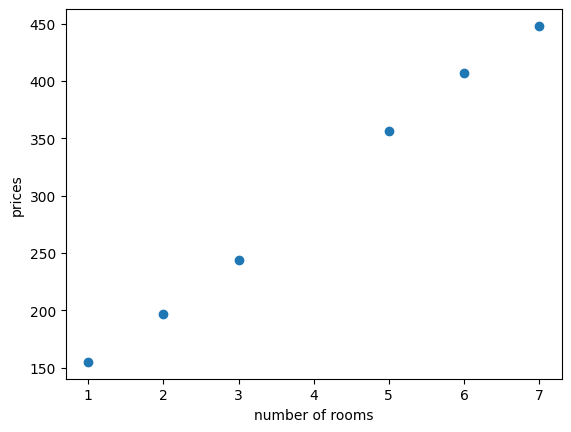

In [96]:
utils.plot_points(features,labels)

# Running the linear regression algorithm

The linear regression algorithm consists of:

- Starting with random weights
- Iterating the square (or simple, or absolute) trick many times.

(np.float64(51.04430678220095), np.float64(91.59448307644864))

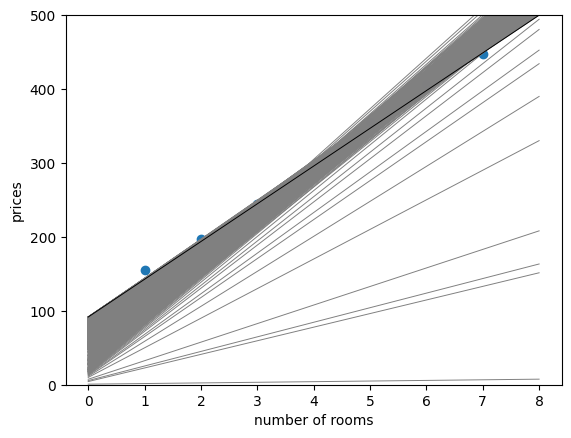

In [97]:
plt.ylim(0,500)
linear_regression(features=features,labels=labels)

# root mean square error function

In [98]:
def rmse(labels, predictions):
    n = len(labels)
    differences = np.subtract(labels,predictions)
    return np.sqrt(1.0/n *np.dot(differences,differences))

# Update linear regression function with integrating rmse


Price per room: 50.65781332767556
Base price: 99.79504258184782


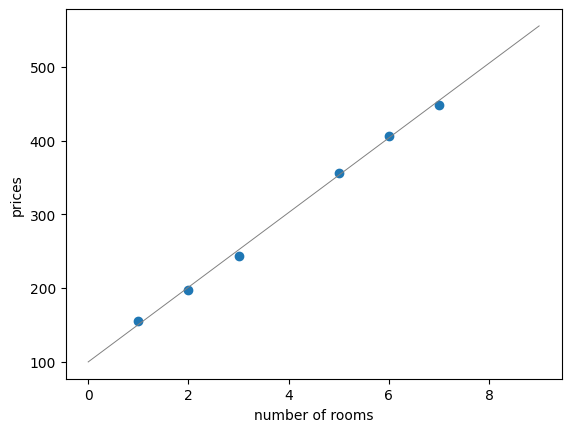

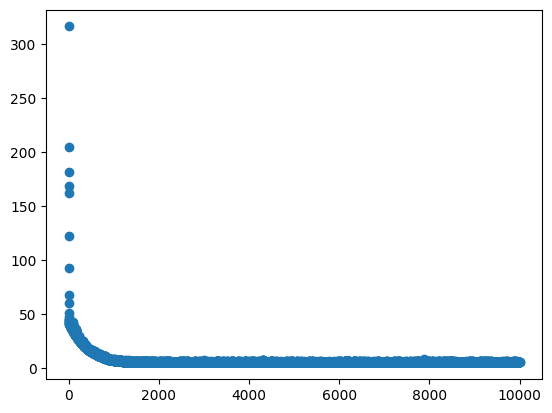

(np.float64(50.65781332767556), np.float64(99.79504258184782))

In [99]:
def linear_regression_v1(features, labels, learning_rate = 0.01, epochs = 1000):
    price_per_room = random.random()
    base_price = random.random()
    errors = []
    for epoch in range(epochs):
        predictions = features*price_per_room + base_price
        errors.append(rmse(predictions=predictions, labels=labels))
        i = random.randint(0,len(labels) - 1)
        price_per_room , base_price = square_trick(base_price=base_price,price_per_room=price_per_room,num_rooms=features[i],price=labels[i],learning_rate=learning_rate)
    
    utils.plot_points(features,labels)
    utils.draw_line(slope=price_per_room,y_intercept=base_price,starting=0,ending=9)
    print('Price per room:', price_per_room)
    print('Base price:', base_price)
    plt.show()
    plt.scatter(range(len(errors)),errors)
    plt.show()
    return price_per_room,base_price

linear_regression_v1(features,labels,learning_rate=0.01,epochs= 10000)